# Rendimiento Electoral del Peronismo en Elecciones Generales — Argentina 2011-2023

**Pregunta de investigación:**
¿Cuál ha sido el rendimiento electoral de las distintas coaliciones formadas por el Partido Peronista en cada una de las provincias de la República Argentina en las elecciones generales del período 2011-2023?

**Decisión metodológica:** se trabaja únicamente con elecciones generales (no PASO), ya que el objetivo es capturar la intención de voto "firme" del electorado al momento de definir representación, y no el efecto de "termómetro electoral" propio de las primarias. Se consideran los cuatro procesos electorales presidenciales del período: 2011, 2015, 2019 y 2023.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## 1. Carga de datos

In [2]:
# Dataset público de resultados electorales por provincia, elección y partido (2011-2023)
elecciones = pd.read_excel("../data/datos_electorales_err.xlsx")
elecciones.head(5)

,id,Elecciones,Partido,Porcentaje,Votos,Participacion,Electores,Votantes,Bancas
0,BUENOS AIRES,GENERALES 2011,FRENTE PARA LA VICTORIA,56.97,4460986.0,123315.00,10574461,8693248,NaN
1,BUENOS AIRES,GENERALES 2011,FRENTE AMPLIO PROGRESISTA,2025-01-13 00:00:00,1018572.0,82.21,10574461,8693248,NaN
2,BUENOS AIRES,GENERALES 2011,UNIÃ“N PARA EL DESARROLLO SOCIAL,11.56,905064.0,82.21,10574461,8693248,NaN
3,BUENOS AIRES,GENERALES 2011,BLANCO,9.25,804237.0,82.21,10574461,8693248,NaN
4,BUENOS AIRES,GENERALES 2011,FRENTE POPULAR,6.75,528789.0,82.21,10574461,8693248,NaN


In [3]:
print("Registros totales:", len(elecciones))
elecciones.info()

Registros totales: 3214
<class 'pandas.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             3214 non-null   str    
 1   Elecciones     3214 non-null   str    
 2   Partido        3214 non-null   str    
 3   Porcentaje     3214 non-null   object 
 4   Votos          3209 non-null   object 
 5   Participacion  3214 non-null   float64
 6   Electores      3214 non-null   int64  
 7   Votantes       3214 non-null   int64  
 8   Bancas         170 non-null    float64
dtypes: float64(2), int64(2), object(2), str(3)
memory usage: 226.1+ KB


## 2. Exploración inicial y detección de problemas de calidad de datos

In [4]:
print("Valores faltantes por columna:")
print(elecciones.isnull().sum())

Valores faltantes por columna:
id                  0
Elecciones          0
Partido             0
Porcentaje          0
Votos               5
Participacion       0
Electores           0
Votantes            0
Bancas           3044
dtype: int64


In [5]:
print("Registros de período electoral:")
print(sorted(elecciones["Elecciones"].astype(str).unique()))

Registros de período electoral:
['GENERALES 2011', 'GENERALES 2013', 'GENERALES 2015', 'GENERALES 2017', 'GENERALES 2019', 'GENERALES 2021', 'GENERALES 2023', 'GENERALES 2090', 'PASO 2011', 'PASO 2013', 'PASO 2015', 'PASO 2017', 'PASO 2019', 'PASO 2021', 'PASO 2023', 'PASO 2090']


**Problema detectado:** aparece el valor `"GENERALES 2090"` / `"PASO 2090"`, un año inválido para el período analizado (96 registros, ~3% del dataset). Se excluirá del análisis por tratarse de un error de carga evidente en la fuente.

In [6]:
print("Registros de provincia:")
print(sorted(elecciones["id"].astype(str).unique()))

Registros de provincia:
['BUENOS AIRES', 'CATAMARCA', 'CHACO', 'CHUBUT', 'CIUDAD AUTONOMA DE BUENOS AIRES', 'CORD OBA', 'CORDOBA', 'CORRIENTES', 'Córdoba', 'ENTRE RIOS', 'FORMOSA', 'JUJUY', 'LA PAMPA', 'LA RIOJA', 'MENDOZA', 'MISIONES', 'NEUQUEN', 'RIO NEGRO', 'SALTA', 'SAN JUAN', 'SAN LUIS', 'SANTA CRUZ', 'SANTA FE', 'SANTIAGO DEL ESTERO', 'TIERRA DEL FUEGO', 'TUCUMAN', 'cordoba']


**Problema detectado:** la provincia de Córdoba aparece bajo múltiples variantes ("CORDOBA", "cordoba", "CORD OBA", "Córdoba"), y varios nombres de provincia y partido tienen errores de codificación de caracteres (ej. `"UNIÃ“N"` en lugar de `"UNIÓN"`). Ambos problemas se corrigen en la sección de limpieza.

In [7]:
print("Muestra de valores de la columna Votos (tipos mixtos):")
print(elecciones["Votos"].apply(type).value_counts())
elecciones[["Votos"]].head(3)

Muestra de valores de la columna Votos (tipos mixtos):
Votos
<class 'str'>                  3200
<class 'int'>                     8
<class 'float'>                   5
<class 'datetime.datetime'>       1
Name: count, dtype: int64


,Votos
0,4460986.0
1,1018572.0
2,905064.0


**Problema detectado:** la columna `Votos` combina dos convenciones numéricas distintas dentro del mismo dataset — puntos como separador de miles (ej. `"4.460.986"`) y puntos como separador decimal (ej. `"160679.0"`). Aplicar una sola regla de limpieza a ambos formatos generaría valores hasta 10 veces mayores a los reales. Se resuelve con una regla condicional según la cantidad de puntos presentes en cada valor (ver sección 3.3).

## 3. Limpieza y transformación de datos

### 3.1 Normalización de nombres de provincia

In [8]:
elecciones["id"] = elecciones["id"].astype(str).str.strip()
elecciones["id"] = (elecciones["id"]
                     .str.replace("Ã“", "Ó", regex=False)
                     .str.replace("Ã‘", "Ñ", regex=False))
elecciones["id"] = elecciones["id"].str.upper()
elecciones["id"] = elecciones["id"].str.replace("CORD OBA", "CORDOBA", regex=False)
elecciones["id"] = elecciones["id"].replace({"CÓRDOBA": "CORDOBA"})

print("Provincias únicas tras limpieza:", elecciones["id"].nunique())
sorted(elecciones["id"].unique())

Provincias únicas tras limpieza: 24


['BUENOS AIRES',
 'CATAMARCA',
 'CHACO',
 'CHUBUT',
 'CIUDAD AUTONOMA DE BUENOS AIRES',
 'CORDOBA',
 'CORRIENTES',
 'ENTRE RIOS',
 'FORMOSA',
 'JUJUY',
 'LA PAMPA',
 'LA RIOJA',
 'MENDOZA',
 'MISIONES',
 'NEUQUEN',
 'RIO NEGRO',
 'SALTA',
 'SAN JUAN',
 'SAN LUIS',
 'SANTA CRUZ',
 'SANTA FE',
 'SANTIAGO DEL ESTERO',
 'TIERRA DEL FUEGO',
 'TUCUMAN']

### 3.2 Definición del espacio peronista y del recorte temporal

In [9]:
# Coaliciones y denominaciones asociadas al espacio peronista/justicialista a lo largo del período
peronismo = (
    "UNIDAD CIUDADANA", "FRENTE DE TODOS", "UNION POR LA PATRIA", "FRENTE PARA LA VICTORIA",
    "ALIANZA FRENTE PARA LA VICTORIA", "FRENTE PARA LA VICTORIA RIOJANA", "FRENTE JUSTICIALISTA",
    "FRENTE JUSTICIALISTA PARA LA VICTORIA", "PARTIDO DE LA VICTORIA", "ALIANZA PARA LA VICTORIA",
    "FUERZA PATRIA", "MOVIMIENTO POLO SOCIAL LA TERCERA POSICION DE LA GENTE", "PARTIDO JUSTICIALISTA"
)

# Elecciones generales presidenciales del período 2011-2023
presidenciales = ("GENERALES 2011", "GENERALES 2015", "GENERALES 2019", "GENERALES 2023")

elecciones["Elecciones"] = elecciones["Elecciones"].astype(str).str.strip()
elecciones["Partido"] = elecciones["Partido"].astype(str).str.strip().str.upper()

tabla_filtrada = elecciones[
    elecciones["Elecciones"].isin(presidenciales) & elecciones["Partido"].isin(peronismo)
].copy()

print("Registros tras filtrar por elección y partido:", len(tabla_filtrada))
tabla_filtrada.head()

Registros tras filtrar por elección y partido: 91


,id,Elecciones,Partido,Porcentaje,Votos,Participacion,Electores,Votantes,Bancas
0,BUENOS AIRES,GENERALES 2011,FRENTE PARA LA VICTORIA,56.97,4460986.0,123315.00,10574461,8693248,NaN
19,BUENOS AIRES,GENERALES 2015,FRENTE PARA LA VICTORIA,37.14,3212919.0,78.58,12033279,9455259,NaN
35,BUENOS AIRES,GENERALES 2019,FRENTE DE TODOS,52.58,4868198.0,82.37,11995955,9881630,19.0
51,BUENOS AIRES,GENERALES 2023,UNION POR LA PATRIA,43.65,3993120.0,77.43,13124435,10161648,16.0
194,CATAMARCA,GENERALES 2011,FRENTE PARA LA VICTORIA,68.27,120806.0,73.33,254265,186455,NaN


### 3.3 Limpieza del campo `Votos` (formato numérico mixto)

> **Nota de corrección:** en una versión previa de este análisis se aplicó una única regla de limpieza (eliminar todos los puntos, asumiendo que siempre representaban separador de miles). Esto multiplicaba por 10 los valores que en realidad usaban el punto como separador decimal (ej. `"160679.0"` se convertía incorrectamente en `1606790`), generando proporciones de voto sobre el padrón superiores al 400% en varias provincias. La función siguiente distingue ambos formatos según la cantidad de puntos presentes en cada valor.

In [10]:
def clean_votos(v):
    if isinstance(v, str):
        v = v.strip()
        if v.count(".") >= 2:
            v = v.replace(".", "")       # separador de miles, ej "4.460.986"
        v = v.replace(",", ".")
        try:
            return float(v)
        except ValueError:
            return np.nan
    elif isinstance(v, (int, float)):
        return float(v)
    else:
        return np.nan   # valores corruptos (ej. tipo fecha por auto-formato de Excel)

tabla_filtrada["Votos_clean"] = tabla_filtrada["Votos"].apply(clean_votos)
print("Valores no interpretables tras limpieza:", tabla_filtrada["Votos_clean"].isnull().sum())

Valores no interpretables tras limpieza: 0


### 3.4 Cálculo de la proporción de votos sobre el padrón electoral

In [11]:
tabla_filtrada["prop_padron"] = (tabla_filtrada["Votos_clean"] / tabla_filtrada["Electores"]) * 100

print("Rango de la métrica calculada:")
print(tabla_filtrada["prop_padron"].describe()[["min", "max", "mean"]])

Rango de la métrica calculada:
min       9.025768
max     101.225604
mean     30.778026
Name: prop_padron, dtype: float64


**Valor atípico detectado:** un registro (Chubut, 2015) muestra una proporción levemente superior al 100% (101,2%), lo cual es lógicamente imposible y refleja un error en el dato fuente de electores o votos para ese caso puntual. Se conserva en el análisis por tratarse de un desvío menor que no altera el ordenamiento general de resultados; se documenta como limitación conocida.

## 4. Agregación por provincia

Se calcula, para cada combinación provincia-elección, la proporción sobre el padrón, y luego se promedia por provincia a lo largo de los años disponibles. **A diferencia de una versión previa de este notebook, no se sobrescribe la tabla completa filtrando a un solo año antes de agregar** — ese error hacía que el resultado final reflejara solo la elección de 2015 en lugar del promedio de las cuatro elecciones generales del período.

In [12]:
# Promedio por combinación provincia-año (resuelve los 2 casos de duplicados dentro del mismo año)
prov_year = tabla_filtrada.groupby(["id", "Elecciones"], as_index=False)["prop_padron"].mean()

# Promedio final por provincia, sobre los años efectivamente disponibles
resultado = (
    prov_year.groupby("id", as_index=False)
    .agg(prop_padron_promedio=("prop_padron", "mean"), anios_con_datos=("Elecciones", "count"))
    .sort_values("prop_padron_promedio", ascending=False)
    .reset_index(drop=True)
)
resultado["prop_padron_promedio"] = resultado["prop_padron_promedio"].round(2)
resultado.columns = ["Provincia", "Prop. promedio s/ padrón (%)", "Años con datos (de 4)"]
resultado

,Provincia,Prop. promedio s/ padrón (%),Años con datos (de 4)
0,FORMOSA,45.47,4
1,CHUBUT,40.45,4
2,TUCUMAN,39.12,4
3,CHACO,38.41,4
4,SAN JUAN,38.02,4
5,CATAMARCA,37.52,4
6,CORRIENTES,35.76,4
7,BUENOS AIRES,34.97,4
8,ENTRE RIOS,34.60,3
9,RIO NEGRO,32.48,4


**Nota sobre cobertura:** de las 96 combinaciones posibles (24 provincias × 4 elecciones), 7 no registraron ningún partido identificado como parte del espacio peronista bajo los nombres considerados en la sección 3.2 — probablemente variantes de coalición provincial no contempladas en el listado. Esas celdas se excluyen (no se imputan), y el promedio de cada provincia se calcula sobre los años efectivamente disponibles, reflejado en la columna "Años con datos".

## 5. Visualización de resultados

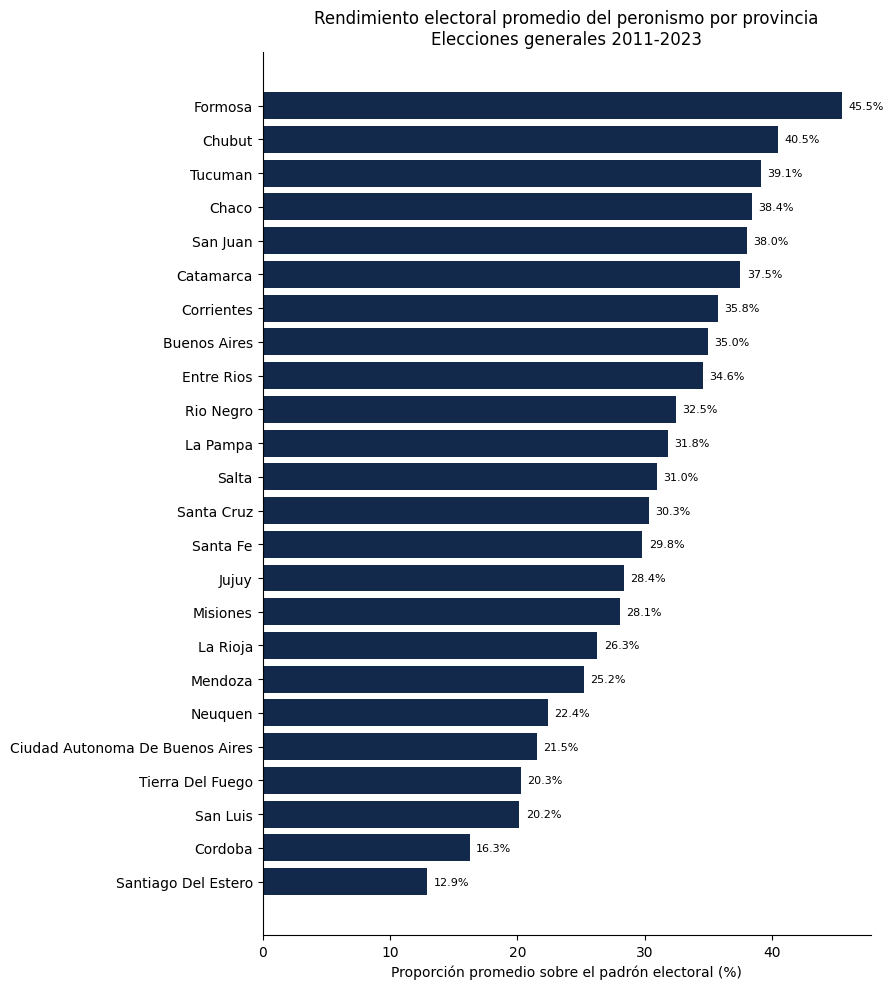

In [13]:
fig, ax = plt.subplots(figsize=(9, 10))
data_plot = resultado.sort_values("Prop. promedio s/ padrón (%)", ascending=True)

ax.barh(data_plot["Provincia"].str.title(), data_plot["Prop. promedio s/ padrón (%)"], color="#13294B")
ax.set_xlabel("Proporción promedio sobre el padrón electoral (%)")
ax.set_title("Rendimiento electoral promedio del peronismo por provincia\nElecciones generales 2011-2023")
for i, v in enumerate(data_plot["Prop. promedio s/ padrón (%)"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Conclusión

A lo largo de las cuatro elecciones generales analizadas (2011, 2015, 2019 y 2023), el distrito electoral donde el espacio peronista concentró su mayor respaldo relativo sobre el padrón fue **Formosa** (45,47%), seguida por **Chubut** (40,45%) y **Tucumán** (39,12%). En el extremo opuesto, **Córdoba** (16,28%, con datos completos para los 4 años) y **San Luis** (20,17%) muestran el menor respaldo relativo. Santiago del Estero registra el valor más bajo (12,94%), pero al contar con datos de solo 2 de los 4 años, este resultado debe interpretarse con mayor cautela que el resto.

El detalle completo de la metodología, el control de calidad de datos y las limitaciones del análisis está documentado en el informe técnico (`informe_final.pdf`) incluido en este repositorio.

**Dashboard interactivo en Looker Studio:** https://datastudio.google.com/reporting/4b697a70-3a3a-49dc-87aa-82358a4c60e7/page/p_0qwy9nwayd/edit